In [1]:
import torch
from kan import *

In [2]:
device = torch.device("cuda:3" if torch.cuda.is_available() else "cpu" )
print(device)

cuda:3


In [ ]:
# kan_mit = KAN(width=[4,2,1], grid=5, k=3, noise_scale=0.1, seed=0, device=device, ckpt_path='../Notebooks/ckpt_path/kan_mit/evaluation')
mit_data = torch.load('../Data/MIT_Data.pt')
# print(mit_data)
mit_dataset =  {
        'train_input': mit_data['train_input'],
        'train_label': mit_data['train_label'],
        'test_input': mit_data['test_input'],
        'test_label': mit_data['test_label']
    }
kan_mit = KAN.loadckpt('../Notebooks/ckpt_path/kan_mit/training/0.1')
kan_mit.get_act(mit_dataset)

checkpoint directory created: ../Notebooks/ckpt_path/kan_mit/evaluation
saving model version 0.0


/tmp/ipykernel_4054993/947515333.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  mit_data = torch.load('../Data/MIT_Data.pt')
/data/huangjh/anaconda/envs/pikan/lib/pytho

In [ ]:
def complex_expression(x):
    """
    Compute the complex expression given input values.

    Args:
        x (list or torch.Tensor): A list or tensor containing the values [x_1, x_2, x_3, x_4].

    Returns:
        torch.Tensor: A tensor.
    """
    # Unpack inputs
    x_1, x_2, x_3, x_4 = x

    # First part of the expression
    part1 = -0.18*torch.arcsin(
                -0.04*(-0.90*x_3 - 1)**2 
                + 0.26*torch.arcsin(-0.40*x_2 - 0.57) 
                + 0.22*torch.sin(0.72*x_1 + 5.36) 
                + 9.39*torch.cos(0.12*x_4 + 0.12) 
                - 9.62) \
            - 0.58*torch.arcsin(
                0.03*(-0.96*x_4 - 1)**2 
                - 0.01*torch.arcsin(-0.32*x_1 - 0.60) 
                + 0.07*torch.arcsin(-0.13*x_3 - 0.80) 
                + 2.38*torch.cos(0.20*x_2 + 0.21) 
                - 3.03
            ) - 0.592287689447403

    # Return the result as a tensor
    return torch.tensor([part1])

In [ ]:
# def complex_expression2(x):
#     """
#     Compute the complex expression given input values.

#     Args:
#         x (list or torch.Tensor): A list or tensor containing the values [x_1, x_2, x_3, x_4].

#     Returns:
#         torch.Tensor: A tensor.
#     """
#     # Unpack inputs
#     x_1, x_2, x_3, x_4 = x

#     # First part of the expression
#     part1 = -0.18253929913044*torch.arcsin(-0.0440303384689311*(-0.898689885626196*x_3 - 1)**2 
#                                            + 0.257530398199236*torch.arcsin(-0.399999856948853*x_2 - 0.567999839782715) 
#                                            + 0.216432435252152*torch.sin(0.720319867134094*x_1 + 5.3648796081543) 
#                                            + 9.38753717958889*torch.cos(0.118800058960915*x_4 + 0.122640058398247) 
#                                            - 9.62172150745934) 
#     - 0.576184391975403*torch.arcsin(0.0305538042862781*(-0.959204380249675*x_4 - 1)**2 
#                                      - 0.0124750325116027*torch.arcsin(-0.319999843835831*x_1 - 0.599999845027924) 
#                                      + 0.0686680342124535*torch.arcsin(-0.128000050783157*x_3 - 0.799999833106995) 
#                                      + 2.38210078592211*torch.cos(0.200159847736359*x_2 + 0.209119856357574) 
#                                      - 3.02674997007088) - 0.592287689447403

#     # Return the result as a tensor
#     return torch.tensor([part1])

In [6]:
# def complex_expression3(x):
#     """
#     Compute the complex expression given input values.

#     Args:
#         x (list or torch.Tensor): A list or tensor containing the values [x_1, x_2, x_3, x_4].

#     Returns:
#         torch.Tensor: A tensor.
#     """
#     # Unpack inputs
#     x_1, x_2, x_3, x_4 = x

#     # First part of the expression
#     part1 = - 0.006*torch.arcsin(
#                 -0.221*(0.158 - x_3)**2 
#                 + 0.258*torch.arcsin(-0.805*x_2 - 0.152) 
#                 + 0.216*torch.sin(1.454*x_1 + 4.613) 
#                 + 9.388*torch.cos(0.207*x_4 + 0.124) 
#                 - 9.622) \
#             - 0.017*torch.arcsin(
#                 0.086*(-x_4 - 0.602)**2 
#                 - 0.012*torch.arcsin(-0.646*x_1 - 0.266) 
#                 + 0.069*torch.arcsin(-0.319*x_3 - 0.607) 
#                 + 2.382*torch.cos(0.403*x_2 + 0.001) 
#                 - 3.027) \
#             + 0.931830509465564

#     # Return the result as a tensor
#     return torch.tensor([part1])

In [7]:
# Access the true values (targets) from the test set
true_values = mit_dataset['test_label'].cpu().numpy()  # Convert to numpy for plotting

# Step 1: Make predictions on the test set using the KAN model
with torch.no_grad():
    test_predictions = kan_mit(mit_dataset['test_input'])

# Step 2: Convert tensors to NumPy arrays for plotting
kan_forecasts = test_predictions.cpu().numpy()

# Step 3: Use complex_expression function to create symbolic_forecast
symbolic_forecast = []
with torch.no_grad():
    for i in range(mit_dataset['test_input'].shape[0]):
        # Extract each input set from the test dataset and pass it to complex_expression
        x = mit_dataset['test_input'][i]
        symbolic_result = complex_expression(x)  # Pass each sample to the complex expression
        symbolic_forecast.append(symbolic_result.cpu().numpy())  # Append to list after converting to numpy

# Convert symbolic_forecast to a NumPy array for easier handling and plotting
symbolic_forecast = np.array(symbolic_forecast)

In [8]:
from sklearn import metrics
def eval_metrix(true_label,pred_label):
    MAE = metrics.mean_absolute_error(true_label,pred_label)
    MAPE = metrics.mean_absolute_percentage_error(true_label,pred_label)
    MSE = metrics.mean_squared_error(true_label,pred_label)
    RMSE = np.sqrt(metrics.mean_squared_error(true_label,pred_label))
    return [MAE,MAPE,MSE,RMSE]
# Assuming `kan_forecasts`, `symbolic_forecast`, and `true_values` are already defined and are NumPy arrays.
kan_metrics = eval_metrix(true_values, kan_forecasts)
symbolic_metrics = eval_metrix(true_values, symbolic_forecast)
# Display the results
print(f"Metrics for KAN forecast: MAE:{kan_metrics[0]}, MAPE:{kan_metrics[1]}, MSE:{kan_metrics[2]}, RMSE:{kan_metrics[3]}")
print(f"Metrics for Symbolic forecast: MAE:{symbolic_metrics[0]}, MAPE:{symbolic_metrics[1]}, MSE:{symbolic_metrics[2]}, RMSE:{symbolic_metrics[3]}")

Metrics for KAN forecast: MAE:0.006716383621096611, MAPE:0.007091301027685404, MSE:9.271354792872444e-05, RMSE:0.009628787636756897
Metrics for Symbolic forecast: MAE:0.7871754169464111, MAPE:0.8242117762565613, MSE:0.6208614706993103, RMSE:0.7879476547241211


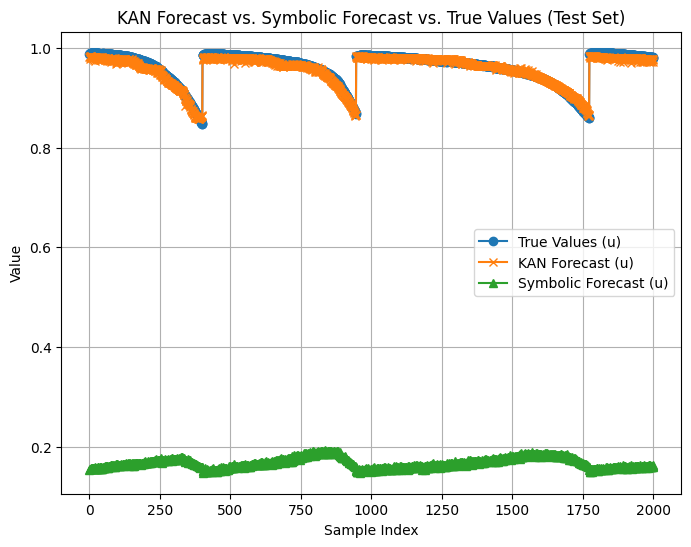

In [9]:
import matplotlib.pyplot as plt

# Set the interval for the samples to plot
interval = 2000

# Create the plot
plt.figure(figsize=(8, 6))

# Plot the KAN forecasts and symbolic forecasts against the true values for id_k1
plt.plot(true_values[:interval], label='True Values (u)', marker='o')
plt.plot(kan_forecasts[:interval], label='KAN Forecast (u)', marker='x')
plt.plot(symbolic_forecast[:interval], label='Symbolic Forecast (u)', marker='^')

# Customize the plot
plt.xlabel('Sample Index')
plt.ylabel('Value')
plt.title('KAN Forecast vs. Symbolic Forecast vs. True Values (Test Set)')
plt.legend()
plt.grid(True)

# Show the plot
plt.show()


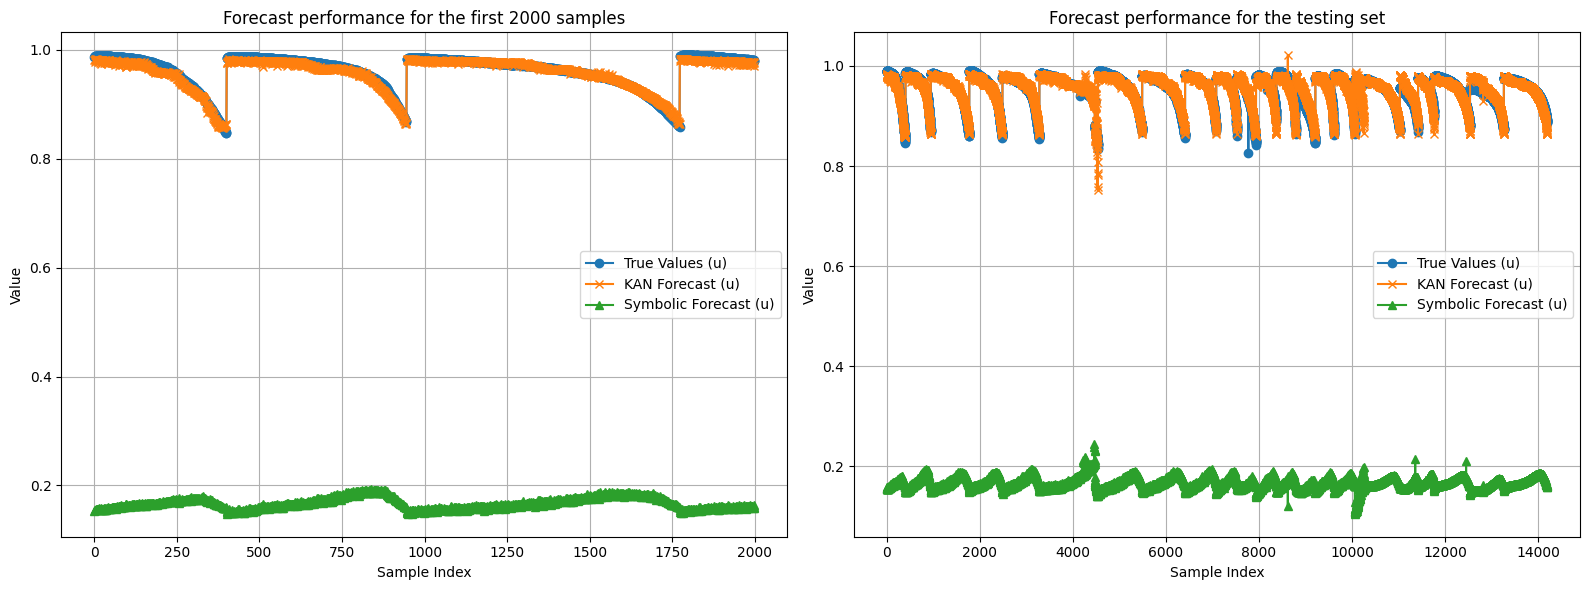

In [10]:
import matplotlib.pyplot as plt

# Set the interval for the first plot (first 50 samples)
interval = 2000

# Create the figure and axes for side-by-side plotting
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot the first interval 
axes[0].plot(true_values[:interval], label='True Values (u)', marker='o')
axes[0].plot(kan_forecasts[:interval], label='KAN Forecast (u)', marker='x')
axes[0].plot(symbolic_forecast[:interval], label='Symbolic Forecast (u)', marker='^')

# Set the title and labels for the first plot
axes[0].set_title(f'Forecast performance for the first {interval} samples')
axes[0].set_xlabel('Sample Index')
axes[0].set_ylabel('Value')
axes[0].legend()
axes[0].grid(True)

# Plot the second interval (entire dataset)
axes[1].plot(true_values, label='True Values (u)', marker='o')
axes[1].plot(kan_forecasts, label='KAN Forecast (u)', marker='x')
axes[1].plot(symbolic_forecast, label='Symbolic Forecast (u)', marker='^')

# Set the title and labels for the second plot
axes[1].set_title('Forecast performance for the testing set')
axes[1].set_xlabel('Sample Index')
axes[1].set_ylabel('Value')
axes[1].legend()
axes[1].grid(True)

# Adjust layout and show the plot
plt.tight_layout()
plt.show()

In [11]:
# Save the plot to a specific location
save_path = '../Images/kan_mit/paper_img/reality_vs_Kan_vs_symbolic.png'  # Change this path as needed
plt.savefig(save_path, format='png', dpi=300, bbox_inches='tight')
print("image saved at "+save_path)

image saved at ../Images/kan_mit/paper_img/reality_vs_Kan_vs_symbolic.png


<Figure size 640x480 with 0 Axes>

In [ ]:
import gc
torch.cuda.empty_cache()
gc.collect()

4371

: 